# Use features to create CBMs of pretrained classifiers


### Prepare dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from settings import *

In [2]:
from utils.downloader import image_downloader
skip_download = True

if not skip_download:
    # categories = {"depth" : { "symbolic" : ["Mannerism (Late Renaissance)"]} }
    categories, deleted = image_downloader(base="wikiart_composed_with_concepts", categories=categories, sample_size=sample_size, image_size=image_size, skip_downloads=skip_download)

    deleted

### Refit a model

In [3]:
import torch, torchvision
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)
print(f"CUDA is available: {torch.cuda.is_available()}.", f"Activated version of CUDA is {torch.version.cuda}.", torch.cuda.device(0))
print(f"Volta's gencode (sm_86) for RTX 3050 and 3070 is in arch_list: {'sm_86' in torch.cuda.get_arch_list()}.")

torch version: 2.4.0
torchvision version: 0.19.0
CUDA is available: True. Activated version of CUDA is 12.4. <torch.cuda.device object at 0x70e399e70dd0>
Volta's gencode (sm_86) for RTX 3050 and 3070 is in arch_list: True.


In [4]:
concepts = pd.read_parquet(root/ "data/semantic_concepts.parquet")
concept_labels = concepts.iloc[:, 4:].columns.tolist()
n_concepts = len(concept_labels)
conceptualized = pd.read_parquet(root/ "data/wikiart_composed_with_concepts.parquet")

display(concepts)
display(concept_labels)
conceptualized.sample(5)

,century,style,breath,depth,contemporary,figurative,geometrical,pattern,brushstrokes,fixed-pallete,...,outline,focused,minimalism,texture,isometric,perspective,dynamic,balanced,proportional,contained
0,20.5,Hard Edge Painting,abstract,NaN,1.0,0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN
1,20.0,Concretism,abstract,NaN,1.0,0,1.0,1.0,NaN,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,NaN,NaN
2,20.0,Suprematism,abstract,symbolic,1.0,0,1.0,0.0,NaN,1.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,1.0
3,20.0,Abstract Art,abstract,NaN,1.0,0,0.0,0.0,1.0,NaN,...,0.0,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,NaN
4,20.0,Abstract Expressionism,abstract,iconic,1.0,0,NaN,0.0,1.0,0.0,...,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
5,20.5,Action painting,abstract,iconic,1.0,0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
6,15.0,Northern Renaissance,concrete,NaN,0.0,1,0.0,0.0,0.0,0.0,...,0.0,NaN,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
7,20.0,Hyper-Realism,concrete,iconic,1.0,1,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,NaN,1.0,1.0,1.0
8,17.0,Tenebrism,concrete,NaN,0.0,1,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
9,19.0,Academicism,concrete,iconic,0.0,1,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0


['contemporary',
 'figurative',
 'geometrical',
 'pattern',
 'brushstrokes',
 'fixed-pallete',
 'contour',
 'outline',
 'focused',
 'minimalism',
 'texture',
 'isometric',
 'perspective',
 'dynamic',
 'balanced',
 'proportional',
 'contained']

,artistName,title,year,style,genre,photography,artemis,emotions,Is painting,Face/body,...,outline,focused,minimalism,texture,isometric,perspective,dynamic,balanced,proportional,contained
contentId,,,,,,,,,,,,,,,,,,,,,
225202,Leonardo da Vinci,Profile of an old man,1505,High Renaissance,sketch and study,0,NaN,NaN,NaN,NaN,...,0.0,1.0,0.5,0.0,0.5,1.0,0.0,1.0,1.0,1.0
251720,Jan Steen,Dancing couple(detail),1663,Baroque,genre painting,0,NaN,NaN,NaN,NaN,...,0.0,0.5,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
9223372032559822634,Tran Van Can,Yellow Girl,<NA>,Post-Impressionism,portrait,0,NaN,NaN,NaN,NaN,...,0.5,1.0,0.5,1.0,0.5,0.5,0.5,1.0,0.5,0.5
9223372032559834879,Yuri Zlotnikov,Untitled Composition #1,1989,Abstract Art,abstract,0,NaN,NaN,NaN,NaN,...,0.0,0.5,0.5,1.0,0.0,0.0,0.5,0.5,0.5,0.5
9223372032559861131,Károly Lotz,Allegory of Earth,1875,Academicism,allegorical painting,0,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0


In [5]:
depth_nan_mask = conceptualized[concept_labels].isna().any(axis=1)

print("Rows with one or more missing concept values:", depth_nan_mask.sum())
print("Unique affected styles:", conceptualized.loc[depth_nan_mask, "style"].nunique())

display(
    conceptualized.loc[
        depth_nan_mask,
        ["style", "depth", *concept_labels]
    ].head(20)
)

Rows with one or more missing concept values: 0
Unique affected styles: 0


,style,depth,contemporary,figurative,geometrical,pattern,brushstrokes,fixed-pallete,contour,outline,focused,minimalism,texture,isometric,perspective,dynamic,balanced,proportional,contained
contentId,,,,,,,,,,,,,,,,,,,


In [6]:
from utils.learners import create_dataloaders_cbm

dataloaders = create_dataloaders_cbm(
    root=container,
    categories=categories,
    dataframe=conceptualized,
    concept_labels=concept_labels,
    show_batch=False, # error in fastai's show_batch function when it gets (class_id, concept_tensor) tuple
)

In [7]:
import torch

def audit_cbm_targets(dl, axis, n_concepts):
    bad_batches = []

    for batch_idx, (xb, yb) in enumerate(dl.train):
        y_class, y_concepts = yb

        y_class_cpu = y_class.detach().cpu()
        y_concepts_cpu = y_concepts.detach().cpu()

        class_ok = (
            y_class_cpu.ndim == 1
            and y_class_cpu.dtype == torch.long
            and y_class_cpu.numel() == xb.shape[0]
            and y_class_cpu.min().item() >= 0
            and y_class_cpu.max().item() < 2
        )

        concepts_ok = (
            y_concepts_cpu.ndim == 2
            and y_concepts_cpu.shape == (xb.shape[0], n_concepts)
            and torch.isfinite(y_concepts_cpu).all().item()
            and torch.isin(
                y_concepts_cpu,
                torch.tensor([0.0, 0.5, 1.0])
            ).all().item()
        )

        if not (class_ok and concepts_ok):
            bad_batches.append({
                "batch": batch_idx,
                "xb": tuple(xb.shape),
                "class_shape": tuple(y_class_cpu.shape),
                "class_dtype": str(y_class_cpu.dtype),
                "class_values": torch.unique(y_class_cpu).tolist(),
                "concept_shape": tuple(y_concepts_cpu.shape),
                "concept_values": torch.unique(y_concepts_cpu).tolist()[:20],
            })

    print(f"{axis}: {len(bad_batches)} invalid training batches")
    return bad_batches

for axis in categories:
    bad = audit_cbm_targets(dataloaders[axis], axis, n_concepts)
    if bad:
        print(bad[:3])

breath: 0 invalid training batches
depth: 0 invalid training batches


In [8]:
from fastai.vision.all import load_learner 
model_choice = "googlenet_10x"

learners = {}
for key in categories.keys():
    learners[key] = load_learner(garage / model_choice / f"{key}.pkl")
    # torch.save(learners[key].model.state_dict(), garage / model_choice / f"{key}_weights.pth")
    learners[f"{key}_model"] = learners[key].model
    learners[f"{key}_backbone"] = learners[f"{key}_model"][0] # learners.model object is otherwise the full model with classification head still attached

/home/trpquo/miniforge-pypy3/envs/fastai/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [9]:
from fastai.vision.all import Learner
from utils.learners import CBMModule, CBMLoss, cbm_accuracy

n_concepts = len(concept_labels)
n_classes = 2
loss_func = CBMLoss(concept_weight=1.0, class_weight=1.0)
print(n_concepts, n_classes)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sanity_check = False

for key in categories.keys():
    learners[f"{key}_cbm"] = CBMModule(learners[f"{key}_backbone"], n_concepts=n_concepts, n_classes=n_classes)
    learners[f"{key}_cbm"].to(device)
    learners[f"{key}_cbm_model"] = Learner(
            dataloaders[key],
            learners[f"{key}_cbm"],
            loss_func=loss_func,
            metrics=[cbm_accuracy],
        )

    if sanity_check:
        model = learners[f"{key}_cbm_model"].model.eval()
        xb, yb = dataloaders[key].valid.one_batch()
        print("xb shape:", xb.shape)
        print("yb[0] shape (class):", yb[0].shape)
        print("yb[1] shape (concepts):", yb[1].shape)

        with torch.no_grad():
            logits, concepts = model(xb)
        print("logits shape:", logits.shape)
        print("concepts shape:", concepts.shape)


        backbone = learners[f"{key}_backbone"]
        print(type(backbone))
        print(backbone)
        backbone.eval()

        xb, yb = dataloaders[key].valid.one_batch()
        print("xb shape:", xb.shape)

        with torch.no_grad():
            out = backbone(xb)

        print("type(out):", type(out))
        if isinstance(out, tuple):
            print("len(out):", len(out))
            for i, o in enumerate(out):
                print(f"out[{i}] shape:", o.shape if hasattr(o, "shape") else "no shape")
        else:
            print("out shape:", out.shape if hasattr(out, "shape") else "no shape")

17 2


In [10]:
for key in categories:
    learn = learners[f"{key}_cbm_model"]

    print(f"\nFine-tuning {key.upper()} CBM")
    learn.fine_tune(
        epochs=5,
        base_lr=1e-3,
        freeze_epochs=1,
    )


Fine-tuning BREATH CBM


epoch,train_loss,valid_loss,cbm_accuracy,time
0,1.109710,1.215597,0.625835,00:29


epoch,train_loss,valid_loss,cbm_accuracy,time
0,0.915686,0.921889,0.937639,00:29
1,0.860639,0.966635,0.902004,00:29
2,0.819037,0.829103,0.919822,00:29
3,0.746933,0.778532,0.951002,00:29
4,0.702367,0.759583,0.951002,00:29



Fine-tuning DEPTH CBM


epoch,train_loss,valid_loss,cbm_accuracy,time
0,1.166811,2.732796,0.481153,00:30


epoch,train_loss,valid_loss,cbm_accuracy,time
0,0.978570,1.056319,0.780488,00:30
1,0.928525,0.945776,0.838137,00:30
2,0.864614,0.909936,0.844789,00:29
3,0.781952,0.845157,0.866962,00:29
4,0.714140,0.832847,0.864745,00:29


In [11]:

for key in categories:
    print(f"\nFitting {key.upper()} CBM")
    learn = learners[f"{key}_cbm_model"]
    learn.unfreeze()
    learn.fit_one_cycle(
        20,
        lr_max=1e-4,
    )


Fitting BREATH CBM


epoch,train_loss,valid_loss,cbm_accuracy,time
0,0.666935,0.755575,0.948775,00:30
1,0.672571,0.746384,0.955457,00:30
2,0.658221,0.744042,0.964365,00:29
3,0.649013,0.734252,0.959911,00:29
4,0.635680,0.726581,0.957684,00:29
5,0.623195,0.709199,0.966592,00:29
6,0.601208,0.704722,0.959911,00:29
7,0.585263,0.699791,0.971047,00:28
8,0.567987,0.690073,0.966592,00:28
9,0.553231,0.694613,0.959911,00:28



Fitting DEPTH CBM


epoch,train_loss,valid_loss,cbm_accuracy,time
0,0.687394,0.835421,0.862528,00:29
1,0.688933,0.828805,0.862528,00:29
2,0.674212,0.832750,0.855876,00:28
3,0.664945,0.822818,0.871397,00:28
4,0.646272,0.808064,0.871397,00:28
5,0.630127,0.815775,0.869180,00:28
6,0.614264,0.800836,0.871397,00:28
7,0.600765,0.799963,0.875831,00:28
8,0.584393,0.793583,0.873614,00:28
9,0.572898,0.814381,0.860310,00:28


In [12]:
for key in categories.keys():
    learner = learners[f"{key}_cbm_model"]
    print(f"Exporting {key.upper()} cbm_model:", type(learner))
    torch.save(learners[f"{key}_cbm_model"].model.state_dict(), garage / model_choice / f"{key}_cbm_weights.pth")
    # learner.export(garage / model_choice / f"{key}_cbm.pkl") # doesn't work because of a local get_y function
    print("OK. Saved.")

Exporting BREATH cbm_model: <class 'fastai.learner.Learner'>
OK. Saved.
Exporting DEPTH cbm_model: <class 'fastai.learner.Learner'>
OK. Saved.


type(learn): <class 'fastai.learner.Learner'>
hasattr plot_loss on learn: False
hasattr model on learn: True
type(learn.model): <class 'utils.learners.CBMModule'>


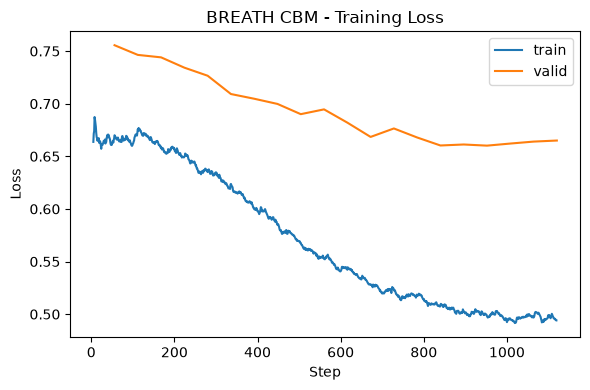

type(learn): <class 'fastai.learner.Learner'>
hasattr plot_loss on learn: False
hasattr model on learn: True
type(learn.model): <class 'utils.learners.CBMModule'>


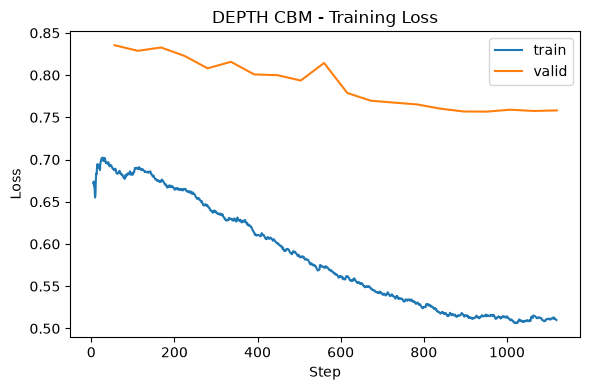

In [13]:
import matplotlib.pyplot as plt

for key in categories.keys():
    learn = learners[f"{key}_cbm_model"]
    print("type(learn):", type(learn))
    print("hasattr plot_loss on learn:", hasattr(learn, "plot_loss"))
    print("hasattr model on learn:", hasattr(learn, "model"))
    print("type(learn.model):", type(learn.model))

    fig, ax = plt.subplots(figsize=(6, 4))
    learn.recorder.plot_loss(ax=ax)  # or with_valid=True if you want val loss too
    ax.set_title(f"{key.upper()} CBM - Training Loss")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    fig.tight_layout()

    fig.savefig(root / f"output/{key}_cbm_loss.png", dpi=150)
    plt.show()
    plt.close(fig)

    # plt.figure()
    # learn.recorder.plot_loss()
    # plt.title(f"{key.upper()} CBM - Training Loss")
    # plt.xlabel("Step")
    # plt.ylabel("Loss")
    # plt.tight_layout()
    # plt.show()